
# 🔍 Explaining Model Predictions with SHAP Values – Random Forest (Titanic Dataset)

**SHAP (SHapley Additive exPlanations)** values offer a powerful way to interpret machine learning models by quantifying how much each feature contributes to a specific prediction. When averaged across all predictions, SHAP values also provide a global view of **feature importance**.

Unlike traditional feature importance methods tied to specific model types, SHAP values are **model-agnostic**. This means they can be used to interpret any model—including complex "black box" models like random forests and neural networks—making them a valuable tool for understanding and comparing model behavior.

In this notebook, we demonstrate how to use SHAP values with a **Random Forest classifier** trained on the Titanic dataset. This allows us to explore both global feature importance and local explanations for individual predictions.

> 📘 For a deeper dive into SHAP values, check out Christoph Molnar’s excellent book chapter. https://github.com/christophM/interpretable-ml-book

> 📚 The official SHAP documentation, including many practical examples, is available at: https://shap.readthedocs.io

---

### ⚠️ Note on SHAP with Random Forests

When using SHAP with **classification models** like Random Forests, SHAP returns a set of values for each class (e.g., "survived" and "not survived"). This differs from models like logistic regression, where SHAP values are typically tied to a single output. As a result, we need slightly different syntax to extract and interpret SHAP values for the class of interest.

In the following sections, we’ll walk through:
- Global feature importance using SHAP
- Local explanations with waterfall plots
- Feature behavior with scatter and beeswarm plots



## Load data and fit model

### Load modules

In [1]:
pip install shap

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Import machine learning methods
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Import shap for shapley values
import shap

### Load data
 Use the 'processed_data.csv' file attatched to the folder of the class

In [3]:
data = pd.read_csv('/content/processed_data.csv')
# Make all data 'float' type
data = data.astype(float)
data.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,AgeImputed,EmbarkedImputed,CabinLetterImputed,...,Embarked_missing,CabinLetter_A,CabinLetter_B,CabinLetter_C,CabinLetter_D,CabinLetter_E,CabinLetter_F,CabinLetter_G,CabinLetter_T,CabinLetter_missing
0,1.0,0.0,3.0,22.0,1.0,0.0,7.2500,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,1.0,1.0,38.0,1.0,0.0,71.2833,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,1.0,3.0,26.0,0.0,0.0,7.9250,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4.0,1.0,1.0,35.0,1.0,0.0,53.1000,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,0.0,3.0,35.0,0.0,0.0,8.0500,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Divide into X (features) and y (labels)

We will separate out our features (the data we use to make a prediction) from our label (what we are truing to predict).
By convention our features are called `X` (usually upper case to denote multiple features), and the label (survived or not) `y`.

In [4]:
# Use `survived` field as y, and drop for X
y = data['Survived'] # y = 'survived' column from 'data'
X = data.drop('Survived',axis=1) # X = all 'data' except the 'survived' column

# Drop PassengerId
X.drop('PassengerId',axis=1, inplace=True)

### Divide into training and tets sets

When we test a machine learning model we should always test it on data that has not been used to train the model.
We will use sklearn's `train_test_split` method to randomly split the data: 75% for training, and 25% for testing.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    test_size=0.25)

### Fit Random Forest model

In [6]:
model = RandomForestClassifier(n_estimators=100,
                               n_jobs=-1,
                               class_weight='balanced',
                               random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

### Predict values and get probabilities of survival

Now we can use the trained model to predict survival. We will test the accuracy of both the training and test data sets.

In [7]:
# Predict training and test set labels
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Predict probabilities of survival
y_prob_train = model.predict_proba(X_train)
y_prob_test = model.predict_proba(X_test)

### Calculate accuracy

In this example we will measure accuracy simply as the proportion of passengers where we make the correct prediction.

In [8]:
accuracy_train = np.mean(y_pred_train == y_train)
accuracy_test = np.mean(y_pred_test == y_test)

print (f'Accuracy of predicting training data = {accuracy_train:0.3f}')
print (f'Accuracy of predicting test data = {accuracy_test:0.3f}')

Accuracy of predicting training data = 0.984
Accuracy of predicting test data = 0.794


## Examining the model importances
Feature importance tells you how useful or valuable each feature (or column) in your dataset is in predicting the target variable.

In a Random Forest, which is an ensemble of decision trees, feature importance is calculated based on how much each feature reduces impurity (like Gini impurity or entropy) across all the trees in the forest.

Here :
1. We store the **feature importances** from the model in a variable.
2. We create a **DataFrame** to organize and display these importances.
3. Finally, we output the top five most important features.


In [9]:
features = list(X_train)

feature_importances = model.feature_importances_

importances = pd.DataFrame(index=features)
importances['importance'] = feature_importances
importances['rank'] = importances['importance'].rank(ascending=False).values
importances.sort_values('rank').head()

,importance,rank
male,0.238135,1.0
Fare,0.235720,2.0
Age,0.213044,3.0
CabinNumber,0.051892,4.0
Pclass,0.051791,5.0


The three most influential features are:

* *male* (gender)
* *Fare*
* *age*

Note: random forest importances do not tell us anything about the direction of effect of features (if they have a positive or negative influence)

## Get Shapley values

We use the `shap_values` method from the SHAP library to get Shapley values.


This code block uses SHAP to compute feature importance for a Random Forest model. Here's what each part does:

1. **Get feature names**: Extracts the list of feature names from the training dataset (`X_train`).

2. **Create SHAP explainer**: Initializes a `TreeExplainer` using the trained model and a sample of 100 rows from the training data as the background dataset. We pass a sample to the explainer to speed up Shap (which can be slow with random forests - these values are used as expected baseline values for features).

3. **Compute SHAP values**: Calculates SHAP values for both the training and test datasets. The values for class 1 (positive class in binary classification) are extracted using `[:,:,1]`. We use the `explainer` method from the SHAP library to get Shapley values along with other data.

[`check_additivity`](https://shap-lrjball.readthedocs.io/en/latest/generated/shap.TreeExplainer.html?highlight=check_additivity) has been disabled as the fit reported a small differnce between between predicted probability and baseline probability with all Shap values summed.

4. **Mean SHAP values**: Computes the average SHAP value for each feature across all training samples. This shows the average contribution of each feature to the model's predictions.

5. **Mean absolute SHAP values**: Computes the average of the absolute SHAP values for each feature. This reflects the overall importance of each feature, regardless of whether its effect is positive or negative.

This analysis helps interpret the model's behavior and compare SHAP-based feature importances with those provided directly by the model.










In [10]:
# Get list of features
features = list(X_train)

# Train explainer on Training set
explainer = shap.TreeExplainer(model,
                               X_train.sample(100))

# Get Shap values (extended version has other data returned as well as shap values)
shapley_values_train_extended = explainer(X_train, check_additivity=False)
shapley_values_train = shapley_values_train_extended.values[:,:,1]

shapley_values_test_extended = explainer(X_test, check_additivity=False)
shapley_values_test = shapley_values_test_extended.values[:,:,1]

# Calculate mean Shapley value for each feature in training set
importances['mean_shapley_values'] = np.mean(shapley_values_train, axis=0)

# Calculate mean absolute Shapley value for each feature in training set
# This will give us the average importance of each feature
importances['mean_abs_shapley_values'] = np.mean(
    np.abs(shapley_values_train),axis=0)

 98%|===================| 1309/1336 [00:36<00:00]       

Add Shapley values to coefficient table.

In [11]:
importances.sort_values(by='importance', ascending=False).head()
importances.head(10)

,importance,rank,mean_shapley_values,mean_abs_shapley_values
Pclass,0.051791,5.0,0.014635,0.053646
Age,0.213044,3.0,0.009160,0.051425
SibSp,0.049641,6.0,-0.000760,0.018892
Parch,0.037600,7.0,0.001275,0.013413
Fare,0.235720,2.0,0.013608,0.061467
AgeImputed,0.019413,8.0,0.007022,0.022892
EmbarkedImputed,0.000133,23.0,0.000014,0.000014
CabinLetterImputed,0.007557,13.0,0.000668,0.004520
CabinNumber,0.051892,4.0,0.002250,0.028486
CabinNumberImputed,0.018340,9.0,0.001476,0.020493


Sor to get top 10 influenctial features by co-effieceints or Shapley

In [12]:
# Get top 10 features
importance_top_10 = \
    importances.sort_values(by='importance', ascending=False).head(10).index
shapley_top_10 = \
    importances.sort_values(
    by='mean_abs_shapley_values', ascending=False).head(10).index

# Add to DataFrame
top_10_features = pd.DataFrame()
top_10_features['importances'] = importance_top_10.values
top_10_features['Shapley'] = shapley_top_10.values

# Display
top_10_features

,importances,Shapley
0,male,male
1,Fare,Fare
2,Age,Pclass
3,CabinNumber,Age
4,Pclass,CabinNumber
5,SibSp,AgeImputed
6,Parch,CabinNumberImputed
7,AgeImputed,Embarked_S
8,CabinNumberImputed,SibSp
9,Embarked_S,Embarked_C


We can see a lot of overlap between the most import fatures as estimated by coefficients and those estimated using mean absolute Shapley values. But they are not identical.

Plot comparison of Shapley and model coefficients:

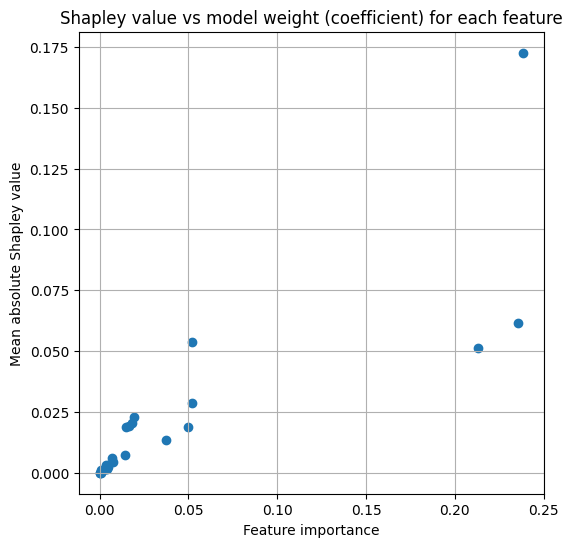

In [13]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# Plot points
x = importances['importance']
y = importances['mean_abs_shapley_values']

ax.scatter(x, y)
ax.set_title('Shapley value vs model weight (coefficient) for each feature')
ax.set_ylabel('Mean absolute Shapley value')
ax.set_xlabel('Feature importance')

plt.grid()
plt.show()

The graph shows that only a few features have both high model importance and high SHAP values, meaning they are consistently influential in the model and have a strong impact on predictions. Most features cluster near the origin, indicating they have little influence.

## Plots of Shapley values

### [Summary Plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html)

The `summary_plot` using a `plot_type` option of `bar` gives us the overall importance of each feature across the population.

Here we limit the num,ber of features shown to 15 (default is 20).

 This approach is quite similar to the standard feature importance method used in traditional machine learning models. Here, we’re looking at the mean SHAP values for each feature.

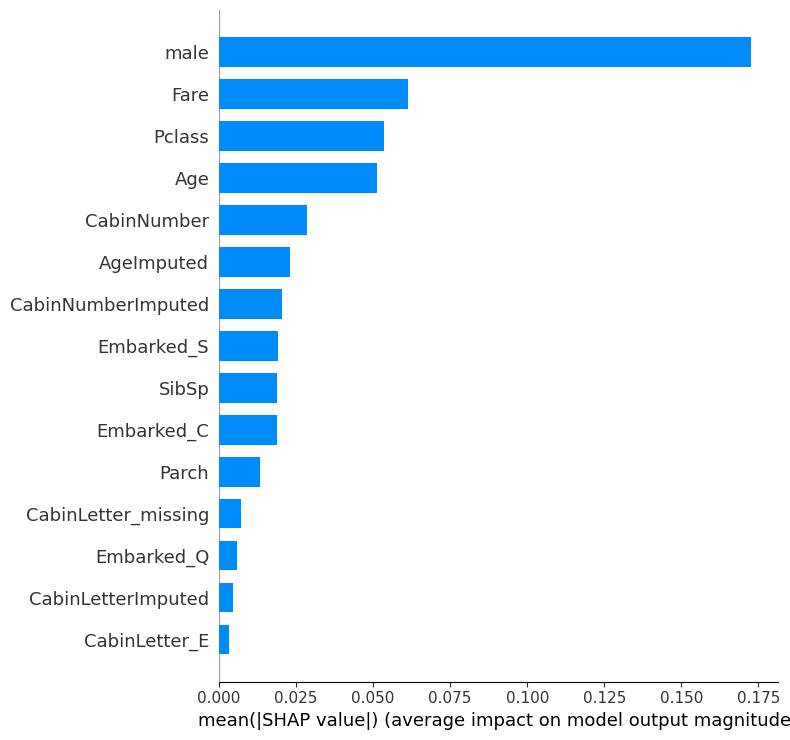

In [14]:
fig = plt.figure(figsize=(6,6))

shap.summary_plot(shap_values = shapley_values_train,
                  features = X_train.values,
                  feature_names = X_train.columns.values,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.tight_layout()
plt.show()

As we saw in the table above, the most important feature by far in determining the likelihood of survival is the gender of the passenger. Following that, fare and passenger class (P-class) come in as the second and third most influential features, respectively. This gives us a high-level understanding of how the model is making its decisions and which features are driving those predictions.

## Summary Plot - Beeswarm

### [Beeswarm Plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html)

Without specifying a `plot_type` option of `bar`, `summary_plot` gives us a *beeswarm* plot, showing the Shapley values for all instances.


A SHAP beeswarm plot shows how each feature in your dataset influences the model’s predictions—both in strength and direction.

- Each dot represents a single prediction for one data point.
- The position on the x-axis shows how much that feature pushed the prediction higher or lower (the SHAP value).
- The color shows the actual value of the feature (e.g., red for high, blue for low).  

One important note is that the SHAP values here are expressed in terms of log-odds of survival. While log-odds can be a bit abstract, they essentially transform the probability scale (0 to 1) into a scale that stretches from negative to positive infinity, making it easier to see the impact of features on predictions.

How to Read It:
- If dots are far to the right, that feature increased the prediction (e.g., higher chance of survival).
- If dots are far to the left, that feature decreased the prediction.
Dense areas show where many predictions were affected similarly.
- For binary features like gender, you’ll see two color groups (e.g., male vs. female).
- For continuous features like age or fare, you’ll see a gradient of colors.


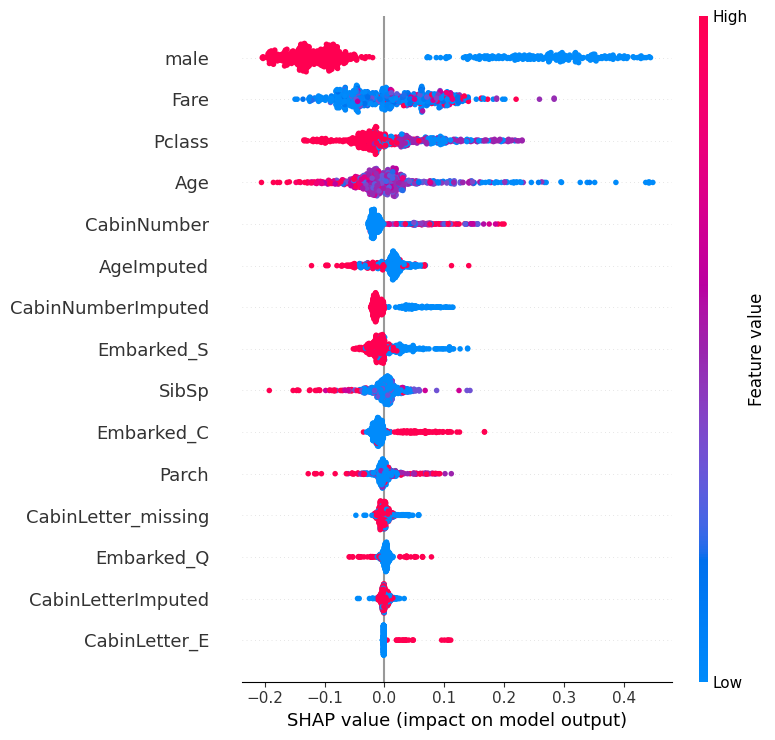

In [15]:
fig = plt.figure(figsize=(6,6))

shap.summary_plot(shap_values = shapley_values_train,
                  features = X_train.values,
                  feature_names = X_train.columns.values,
                  max_display=15,
                  show=False)
plt.tight_layout()
plt.show()


 For the gender class, we can see that being male tends to decrease the SHAP value, lowering the predicted likelihood of survival, while being female increases it.

For features like passenger class, higher values (e.g., third class) are associated with lower survival odds, which aligns with what we might expect. Continuous features like age show a gradient—higher ages tend to reduce survival likelihood, while lower ages increase it. Overall, this plot gives a more detailed and intuitive view of how the model is making its predictions.

##  Waterfall Plot
### [Waterfall Plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/waterfall.html)

A SHAP waterfall plot shows how a single prediction was made by your model. It breaks down the prediction step by step, showing how each feature pushed the prediction up or down from the model’s baseline (average prediction). These are shown as the effect on [*log odds ratio*](https://www.statisticshowto.com/log-odds/) of survival. *Log odds ratio* are usually shown as these are additive, whereas probabilities are not.

Waterfall plots put the most influential features at the top.

How to Read It:
- The plot starts with the base value (the average prediction across all data).
- Then, each feature is added one by one:
If a feature increases the prediction, it’s shown in red (pushing the value up).
If it decreases the prediction, it’s shown in blue (pushing the value down).
-The final bar shows the model’s prediction for that specific instance.

Get locations of passengers with low or high probability of survival.

In [16]:
y_prob = model.predict_proba(X_test)[:,1]

# Get the location of an example each where porbability of survival
# is <0.01 or >0.99

location_low_probability = np.where(y_prob < 0.05)[0][0]
location_high_probability = np.where(y_prob > 0.95)[0][0]

Waterfall plot for passenger with lowest probability of survival:

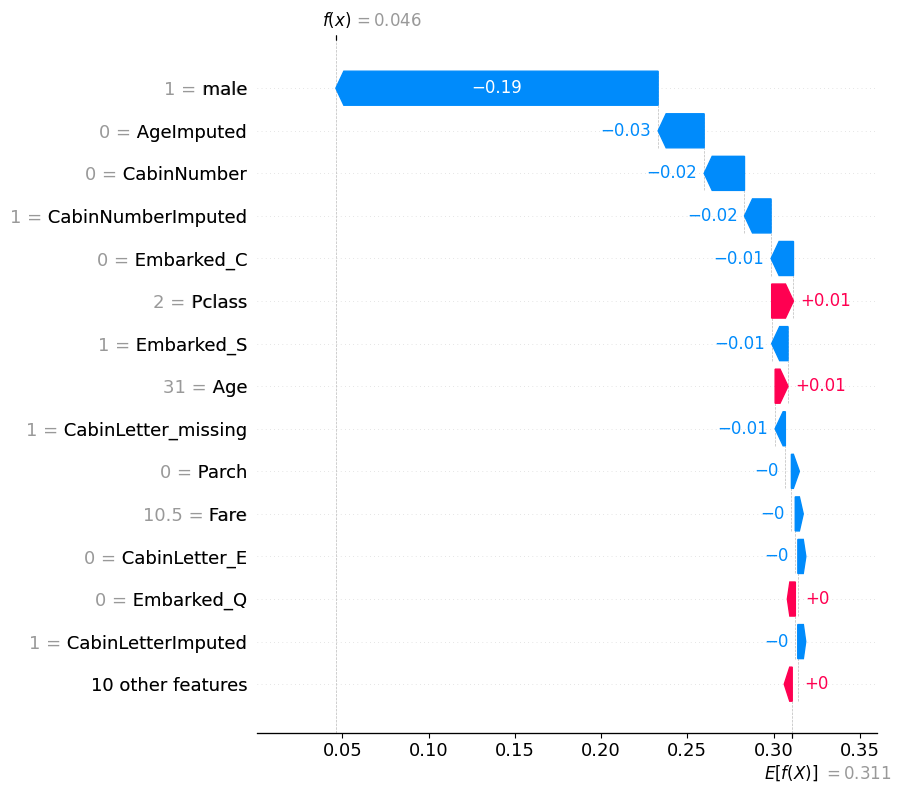

In [17]:
shap.plots.waterfall(shapley_values_test_extended[location_low_probability][:,1],
                     max_display=15)

In the SHAP waterfall plot, we start at the expected value, which represents the average predicted probability of survival across all passengers in the dataset—about  E[f(x)]= 44.6% in this case.

For the specific passenger being analyzed, the model predicted a much lower survival probability of  f(x)=4.6%.

The plot then shows how each feature contributed to moving the prediction from the average down to this final value. For example, being male reduced the survival likelihood by 22%, while other features like cabin number and age also contributed small negative impacts (2-3%).



Waterfall plot for passenger with high probability of survival:

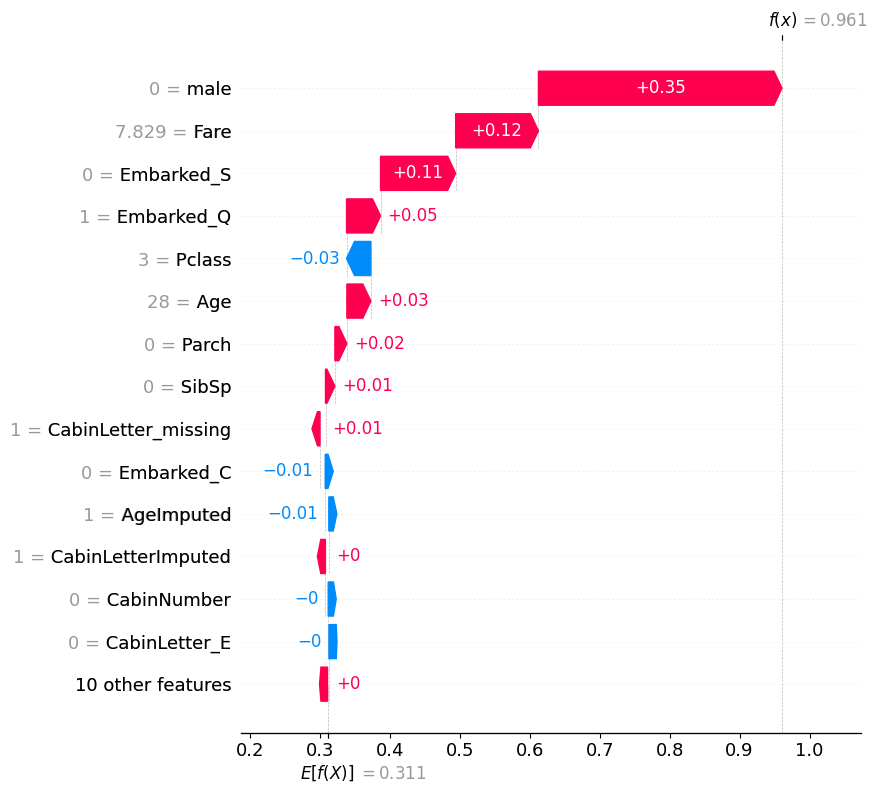

In [18]:
shap.plots.waterfall(shapley_values_test_extended[location_high_probability][:,1],
                     max_display=15)

In this SHAP waterfall plot, we again start with the expected value—the average survival probability across all passengers—which is 44.6%.

For this particular passenger, however, the model predicted a much higher survival probability of 96.1%. The plot shows how this prediction was reached by adding or subtracting the contribution of each feature. For instance, being female (gender = 0) added a significant 31% to the prediction. Boarding at Southampton added another 10%.

Although the passenger was in third class (Third class substracted -5%), which typically lowers survival odds, the overall combination of features still led to a very high predicted probability. This breakdown helps us clearly understand how the model arrived at its decision for this individual.

## Scatter Plot
### [Scatter Plot](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/scatter.html)

A scattter plot for one or more features shows the relationship between the feature value and the Shap value, along with a histogram of the frequency of the feature values.

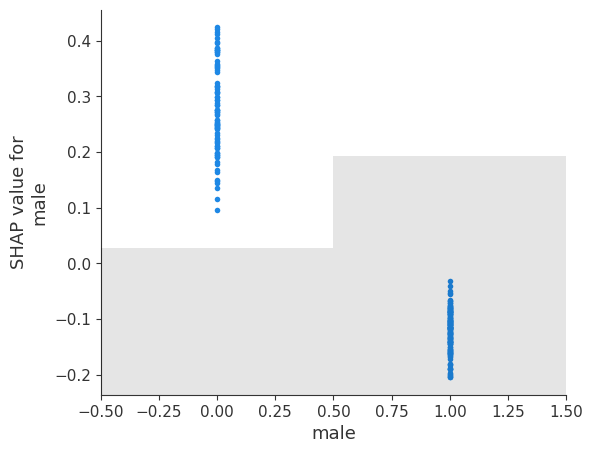

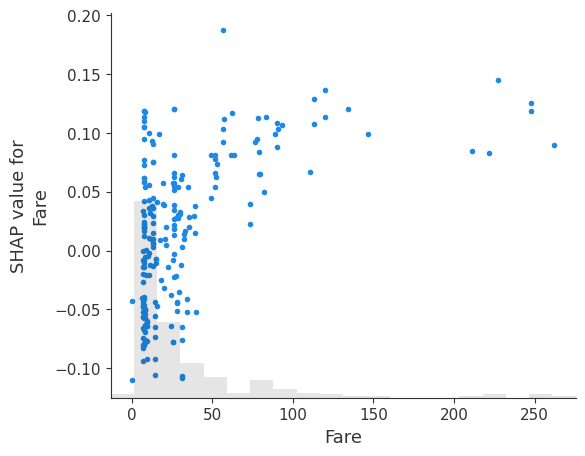

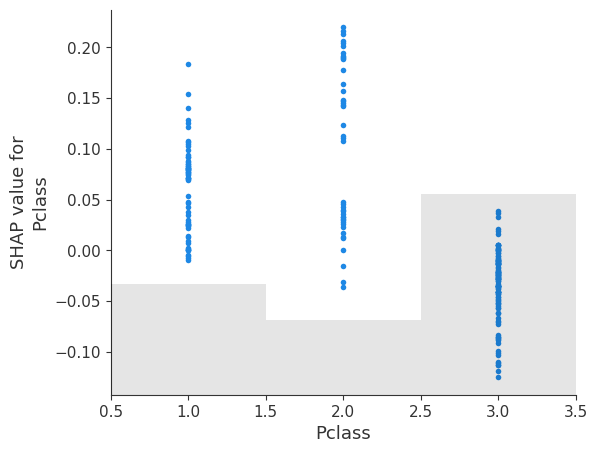

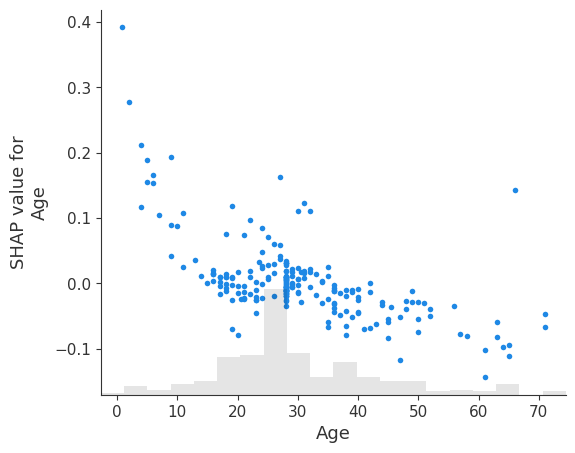

In [19]:
feat_to_show = shapley_top_10[0:4]

for feat in feat_to_show:
    shap.plots.scatter(shapley_values_test_extended[:, feat][:,1],
                       x_jitter=0)

The SHAP scatter plot helps visualize the relationship between a feature’s value and its impact on the model’s prediction. For example, when looking at the gender feature, which is binary (0 for female, 1 for male), we can see that being female results in positive SHAP values, meaning it increases the predicted likelihood of survival. In contrast, being male results in negative SHAP values, decreasing the survival prediction.

For continuous features like fare, the plot shows a range of values on the x-axis and how they influence the SHAP value on the y-axis. Higher fares generally lead to higher SHAP values, indicating a positive effect on survival.

For categorical features like passenger class, we can observe that third-class passengers tend to have negative SHAP values, reducing survival likelihood, while second-class passengers show a broader, more positive distribution.